## Model Comparison: Claude 3.5 Haiku vs. Llama 3.3 70B

Side-by-side evaluation of both LLM backends across RAGAS metrics, PubMedQA benchmark, and manual spot-check quality ratings.

In [4]:
import os
from pathlib import Path


if Path('evaluation/results').exists():
    pass  
elif Path('../evaluation/results').exists():
    os.chdir('..')
else:
    raise RuntimeError('Run this notebook from the HealthInformer project root')

print(f'Working directory: {os.getcwd()}')

Working directory: /Users/ashhad/HealthInformer


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

os.makedirs('figures', exist_ok=True)

# Load RAGAS results
bedrock = pd.read_csv('evaluation/results/ragas_bedrock.csv')
llama = pd.read_csv('evaluation/results/ragas_llama.csv')

metrics = ['faithfulness', 'answer_relevancy', 'llm_context_precision_with_reference', 'context_recall']
labels = ['Faithfulness', 'Answer\nRelevancy', 'Context\nPrecision', 'Context\nRecall']
thresholds = [0.8, 0.7, 0.7, 0.6]

haiku_scores = [bedrock[m].mean() for m in metrics]
llama_scores = [llama[m].mean() for m in metrics]

x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, haiku_scores, width, label='Claude 3.5 Haiku', color='#4A90D9')
bars2 = ax.bar(x + width/2, llama_scores, width, label='Llama 3.3 70B', color='#D4763C')

# Threshold lines
for i, t in enumerate(thresholds):
    ax.plot([i - 0.4, i + 0.4], [t, t], 'k--', linewidth=1, alpha=0.5)
    ax.text(i + 0.42, t, f'{t}', fontsize=8, va='center', color='#666666')

# Value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}',
                ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Score')
ax.set_title('RAGAS Evaluation: Claude 3.5 Haiku vs. Llama 3.3 70B')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/ragas_comparison.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

Both models pass faithfulness (>0.8) and answer relevancy (>0.7). Both miss context precision and recall. This confirms that **retrieval quality, not generation quality, is the system's bottleneck**.

The near-identical context scores are expected since both models share the same HyDE rewriter and vector store.

### PubMedQA + Manual Spot Check

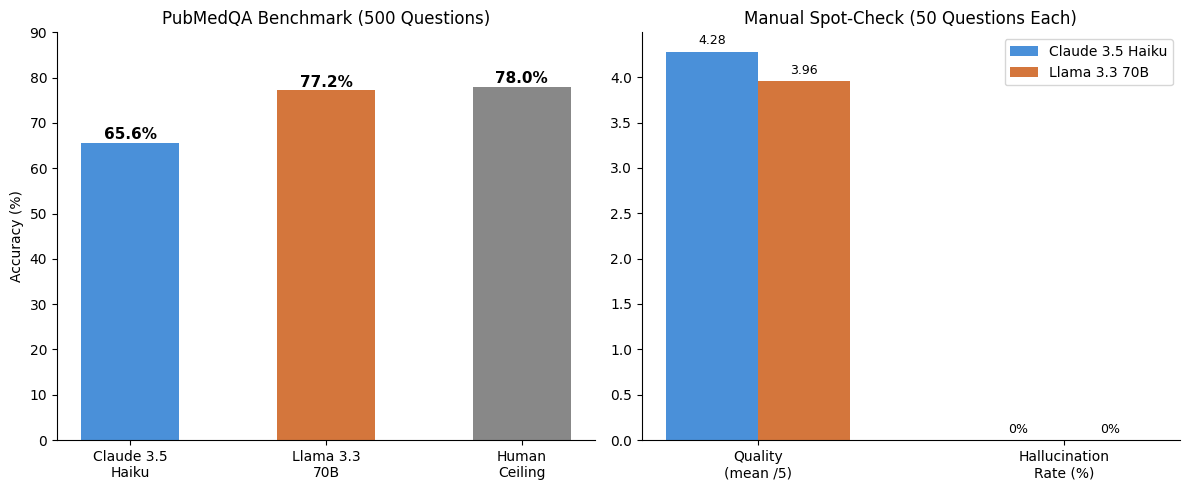

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- PubMedQA ---
models = ['Claude 3.5\nHaiku', 'Llama 3.3\n70B', 'Human\nCeiling']
scores = [65.6, 77.2, 78.0]
colors = ['#4A90D9', '#D4763C', '#888888']

bars = ax1.bar(models, scores, color=colors, width=0.5)
for bar, s in zip(bars, scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f'{s}%', ha='center', fontsize=11, fontweight='bold')

ax1.set_ylabel('Accuracy (%)')
ax1.set_title('PubMedQA Benchmark (500 Questions)')
ax1.set_ylim(0, 90)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Spot-check quality ---
spot_bedrock = pd.read_csv('evaluation/results/spot_check_bedrock.csv')
spot_llama = pd.read_csv('evaluation/results/spot_check_llama.csv')

categories = ['Quality\n(mean /5)', 'Hallucination\nRate (%)']
haiku_vals = [spot_bedrock['quality_1to5'].mean(), 
              (spot_bedrock['has_hallucination'] == 'yes').mean() * 100]
llama_vals = [spot_llama['quality_1to5'].mean(),
              (spot_llama['has_hallucination'] == 'yes').mean() * 100]

x = np.arange(len(categories))
ax2.bar(x - width/2, haiku_vals, width, label='Claude 3.5 Haiku', color='#4A90D9')
ax2.bar(x + width/2, llama_vals, width, label='Llama 3.3 70B', color='#D4763C')

for i, (h, l) in enumerate(zip(haiku_vals, llama_vals)):
    fmt = '{:.2f}' if i == 0 else '{:.0f}%'
    ax2.text(i - width/2, h + 0.08, fmt.format(h), ha='center', fontsize=9)
    ax2.text(i + width/2, l + 0.08, fmt.format(l), ha='center', fontsize=9)

ax2.set_title('Manual Spot-Check (50 Questions Each)')
ax2.set_xticks(x)
ax2.set_xticklabels(categories)
ax2.legend()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/pubmedqa_spotcheck_comparison.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

### Key Findings

- **PubMedQA**: Llama 3.3 70B (77.2%) nearly matches the 78% human ceiling, outperforming Claude Haiku (65.6%). Haiku's lower score seems to come from over-cautious "maybe" responses on definitive yes/no questions.

- **Spot-check**: Both models show 0% hallucination rate. Haiku scores slightly higher on overall quality of the answer (4.28 vs 3.96), producing more polished prose. Llama has more retrieval-related failures but is more honest about limitations.

- **Latency**: Llama averages 5.5s vs Haiku's 13.0s (the only model meeting the <10s target.)